<a href="https://colab.research.google.com/github/tsushchenia/multitask-art-classifier/blob/main/multitask_art_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1
from google.colab import drive
import os

# Mount Google Drive to save model checkpoints
drive.mount('/content/drive')

# Create a directory for the project on Google Drive if it doesn't exist
project_path = '/content/drive/MyDrive/multitask_art_classifier'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Directory created: {project_path}")
else:
    print(f"Directory already exists: {project_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory already exists: /content/drive/MyDrive/Diploma_Project


In [ ]:
#2
from google.colab import files

# Upload the kaggle.json file
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()

    # Configure Kaggle directory and permissions
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API key has been configured.")

Saving kaggle.json to kaggle.json
Kaggle API key has been configured.


In [ ]:
#3
# Download the dataset using Kaggle API
!kaggle datasets download -d ikarus777/best-artworks-of-all-time

# Create a local directory for the dataset
!mkdir -p dataset

# Unzip the dataset quietly
!unzip -q best-artworks-of-all-time.zip -d dataset

print("Dataset downloaded and extracted to /content/dataset")

Dataset URL: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time
License(s): CC-BY-NC-SA-4.0
100% 2.29G/2.29G [00:18<00:00, 133MB/s] 

Dataset downloaded and extracted to /content/dataset


In [ ]:
#4
import pandas as pd
import os

# 1. Check if the file exists
csv_path = 'dataset/artists.csv'
if not os.path.exists(csv_path):
    print(f"ERROR: {csv_path} not found! Please make sure Step 3 ran successfully.")
else:
    # 2. Load metadata
    artists_data = pd.read_csv(csv_path)
    artists_data['name_cleaned'] = artists_data['name'].str.replace(' ', '_')
    artist_genre_map = dict(zip(artists_data['name_cleaned'], artists_data['genre']))

    # 3. Use the list of artists we plan to use
    selected_artist_names = [
        'Vincent_van_Gogh', 'Edgar_Degas', 'Pablo_Picasso',
        'Pierre-Auguste_Renoir', 'Albrecht_Durer', 'Paul_Gauguin',
        'Francisco_Goya', 'Rembrandt', 'Alfred_Sisley', 'Titian'
    ]

    # 4. Filter genres based on our selection
    unique_genres = sorted(list(set([artist_genre_map.get(name, "Unknown") for name in selected_artist_names])))
    genre_to_idx = {genre: i for i, genre in enumerate(unique_genres)}
    idx_to_genre = {i: genre for genre, i in genre_to_idx.items()}

    num_genres = len(unique_genres)
    num_classes = len(selected_artist_names)

    print(f"Metadata ready: {num_classes} Artists, {num_genres} Genres identified.")

Metadata ready: 10 Artists, 8 Genres identified.


In [ ]:
#5
import os
import shutil

selected_artists = [
    'Vincent_van_Gogh', 'Edgar_Degas', 'Pablo_Picasso',
    'Pierre-Auguste_Renoir', 'Albrecht_Durer', 'Paul_Gauguin',
    'Francisco_Goya', 'Rembrandt', 'Alfred_Sisley', 'Titian'
]

# Path where Kaggle unzipped the images
src_dir = 'dataset/images/images'
# Path for filtered dataset
train_dir = 'filtered_dataset'

if not os.path.exists(train_dir):
    os.makedirs(train_dir)

print("Starting to copy images for selected artists...")

for artist in selected_artists:
    artist_src = os.path.join(src_dir, artist)
    artist_dest = os.path.join(train_dir, artist)

    # Copy directory if it exists
    if os.path.exists(artist_src):
        if not os.path.exists(artist_dest):
            shutil.copytree(artist_src, artist_dest)
            print(f"Finished copying: {artist}")
    else:
        print(f"Warning: Directory for {artist} not found!")

print("\nFiltering complete. Your dataset is ready in '/content/filtered_dataset'")

Starting to copy images for selected artists...
Finished copying: Vincent_van_Gogh
Finished copying: Edgar_Degas
Finished copying: Pablo_Picasso
Finished copying: Pierre-Auguste_Renoir
Finished copying: Paul_Gauguin
Finished copying: Francisco_Goya
Finished copying: Rembrandt
Finished copying: Alfred_Sisley
Finished copying: Titian

Filtering complete. Your dataset is ready in '/content/filtered_dataset'


In [ ]:
#6
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Create standard generators first
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 2. Define the multitask wrapper
def multi_output_generator(generator, artist_to_genre_map, genre_to_idx_map):
    inv_artist_indices = {v: k for k, v in generator.class_indices.items()}
    while True:
        data, labels = next(generator)
        artist_indices = np.argmax(labels, axis=1)

        batch_genre_indices = []
        for idx in artist_indices:
            artist_name = inv_artist_indices[idx]
            genre_name = artist_to_genre_map.get(artist_name, "Unknown")
            batch_genre_indices.append(genre_to_idx_map[genre_name])

        genre_labels = tf.keras.utils.to_categorical(batch_genre_indices, num_classes=len(genre_to_idx_map))

        # Returns: (Images), {'genre_out': genre_labels, 'artist_out': artist_labels}
        yield data, {'genre_out': genre_labels, 'artist_out': labels}

# 3. Create wrapped generators
train_multitask_gen = multi_output_generator(train_generator, artist_genre_map, genre_to_idx)
val_multitask_gen = multi_output_generator(val_generator, artist_genre_map, genre_to_idx)

# Synchronizing classes and genres based on actually found folders
found_artist_names = list(train_generator.class_indices.keys())
num_classes = len(found_artist_names)

# Re-filter genres to include only those belonging to found artists
found_genres = sorted(list(set([artist_genre_map.get(name, "Unknown") for name in found_artist_names])))
genre_to_idx = {genre: i for i, genre in enumerate(found_genres)}
idx_to_genre = {i: genre for genre, i in genre_to_idx.items()}
num_genres = len(found_genres)

print(f"Corrected count: {num_classes} Artists and {num_genres} Genres found.")

print("Multitask generators created successfully!")

Found 2989 images belonging to 9 classes.
Found 743 images belonging to 9 classes.
Corrected count: 9 Artists and 7 Genres found.
Multitask generators created successfully!


In [ ]:
#7
import tensorflow as tf
import os

# Define the path to your saved model on Google Drive
model_path = '/content/drive/MyDrive/multitask_art_classifier/best_artist_model.keras'

if os.path.exists(model_path):
    # Load the model directly from the file
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully from Google Drive!")

    class_indices = train_generator.class_indices
    labels = {v: k for k, v in class_indices.items()}
    print("Labels mapping restored:", labels)
else:
    print("No saved model found.")

Model loaded successfully from Google Drive!
Labels mapping restored: {0: 'Alfred_Sisley', 1: 'Edgar_Degas', 2: 'Francisco_Goya', 3: 'Pablo_Picasso', 4: 'Paul_Gauguin', 5: 'Pierre-Auguste_Renoir', 6: 'Rembrandt', 7: 'Titian', 8: 'Vincent_van_Gogh'}


In [ ]:
#8
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

from tensorflow.keras.models import Model

# Shared Base Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

shared_features = layers.GlobalMaxPooling2D()(base_model.output)
shared_features = layers.BatchNormalization()(shared_features)
shared_features = layers.Dropout(0.3)(shared_features)
shared_features = layers.Dense(512, activation='relu')(shared_features)
shared_features = layers.BatchNormalization()(shared_features)

# Head 1: Genre Prediction (Primary)
genre_out = layers.Dense(num_genres, activation='softmax', name='genre_out')(shared_features)

# Head 2: Artist Prediction (Secondary)
shared_features = layers.GlobalMaxPooling2D()(base_model.output)
artist_out = layers.Dense(num_classes, activation='softmax', name='artist_out')(shared_features)


# Build Model
model = Model(inputs=base_model.input, outputs=[genre_out, artist_out])

# Compile with two losses
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={'genre_out': 'categorical_crossentropy', 'artist_out': 'categorical_crossentropy'},
    loss_weights={'genre_out': 1.0, 'artist_out': 0.7}, # Focus more on Genre
    metrics={'genre_out': 'accuracy', 'artist_out': 'accuracy'}
)

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,727,731 (18.03 MB)

 Trainable params: 674,576 (2.57 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [ ]:
#9
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Calculate class weights to handle imbalance
y_train = train_generator.classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

# Path for saving the best model on Google Drive
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = '/content/drive/MyDrive/multitask_art_classifier/best_artist_model.keras'

# Callbacks
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_genre_out_accuracy', # Primary metric
    verbose=1,
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_genre_out_loss',
    patience=7,
    restore_best_weights=True,
    mode='min'
)

callbacks_list = [checkpoint, early_stop]
print("Callbacks updated with explicit 'min/max' modes.")


Callbacks updated with explicit 'min/max' modes.


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - artist_out_accuracy: 0.5023 - artist_out_loss: 1.7837 - genre_out_accuracy: 0.7156 - genre_out_loss: 0.8062 - loss: 2.0547
Epoch 1: val_genre_out_accuracy improved from -inf to 0.71332, saving model to /content/drive/MyDrive/Diploma_Project/best_artist_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 68s 731ms/step - artist_out_accuracy: 0.5025 - artist_out_loss: 1.7831 - genre_out_accuracy: 0.7156 - genre_out_loss: 0.8064 - loss: 2.0546 - val_artist_out_accuracy: 0.5532 - val_artist_out_loss: 1.6062 - val_genre_out_accuracy: 0.7133 - val_genre_out_loss: 0.9115 - val_loss: 2.0808
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - artist_out_accuracy: 0.5835 - artist_out_loss: 1.4339 - genre_out_accuracy: 0.7282 - genre_out_loss: 0.7554 - loss: 1.7591
Epoch 2: val_genre_out_accuracy improved from 0.71332 to 0.72275, saving model to /content/drive/MyDrive/Diploma_Project/best_artist_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 68s 735ms/step - art

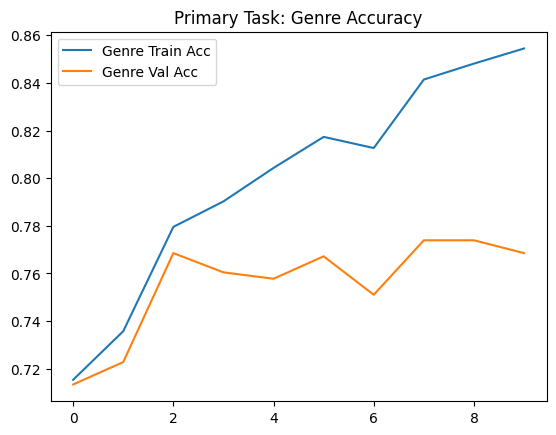

In [ ]:
#10
import matplotlib.pyplot as plt
# Calculate steps
steps_per_epoch = len(train_generator)
val_steps = len(val_generator)

history = model.fit(
    train_multitask_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_multitask_gen,
    validation_steps=val_steps,
    epochs=10,
    callbacks=callbacks_list
)

# Plotting Genre Accuracy specifically
def plot_genre_history(history):
    plt.plot(history.history['genre_out_accuracy'], label='Genre Train Acc')
    plt.plot(history.history['val_genre_out_accuracy'], label='Genre Val Acc')
    plt.title('Primary Task: Genre Accuracy')
    plt.legend()
    plt.show()

plot_genre_history(history)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - artist_out_accuracy: 0.5264 - artist_out_loss: 1.9701 - genre_out_accuracy: 0.6622 - genre_out_loss: 1.0213 - loss: 2.4005
Epoch 1: val_genre_out_accuracy did not improve from 0.77389
94/94 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - artist_out_accuracy: 0.5265 - artist_out_loss: 1.9687 - genre_out_accuracy: 0.6622 - genre_out_loss: 1.0211 - loss: 2.3994 - val_artist_out_accuracy: 0.5922 - val_artist_out_loss: 1.5477 - val_genre_out_accuracy: 0.7093 - val_genre_out_loss: 0.8476 - val_loss: 1.9346
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - artist_out_accuracy: 0.5834 - artist_out_loss: 1.5504 - genre_out_accuracy: 0.6716 - genre_out_loss: 0.9322 - loss: 2.0165
Epoch 2: val_genre_out_accuracy did not improve from 0.77389
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 760ms/step - artist_out_accuracy: 0.5834 - artist_out_loss: 1.5505 - genre_out_accuracy: 0.6717 - genre_out_loss: 0.9320 - loss: 2.0161 - val_artist_out_accuracy: 0.6581 - val_artist_out

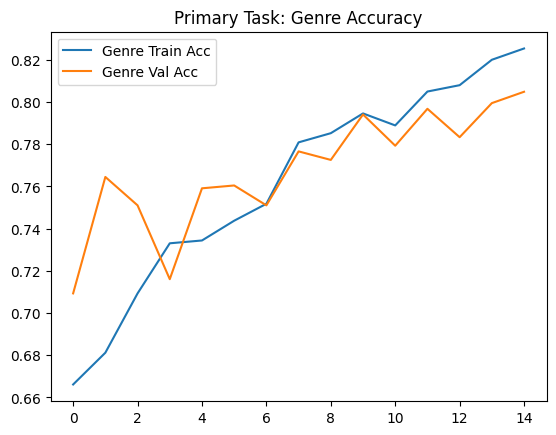

In [ ]:
#11
# 1. Unfreeze the entire base model
base_model.trainable = True

# 2. Re-compile with both outputs and very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss={
        'genre_out': 'categorical_crossentropy',
        'artist_out': 'categorical_crossentropy'
    },
    loss_weights={
        'genre_out': 1.0,
        'artist_out': 0.7
    },
    metrics={
        'genre_out': 'accuracy',
        'artist_out': 'accuracy'
    }
)

# 3. Train using multitask generators
history_finetune = model.fit(
    train_multitask_gen,
    steps_per_epoch=len(train_generator),
    validation_data=val_multitask_gen,
    validation_steps=len(val_generator),
    epochs=15,
    callbacks=callbacks_list
)

# Use the multitask plotting function
plot_genre_history(history_finetune)

In [ ]:
#12
import tensorflow as tf
import os

# 1. Final save
final_model_path = '/content/drive/MyDrive/multitask_art_classifier/best_artist_model.keras'
model.save(final_model_path)
print(f"Model saved to: {final_model_path}")

# 2. Test loading
try:
    test_model = tf.keras.models.load_model(final_model_path)
    print("Verification successful: Model can be loaded correctly!")
except Exception as e:
    print(f"Verification failed: {e}")

Model saved to: /content/drive/MyDrive/Diploma_Project/best_artist_model.keras
Verification successful: Model can be loaded correctly!


Saving pic2.webp to pic2.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


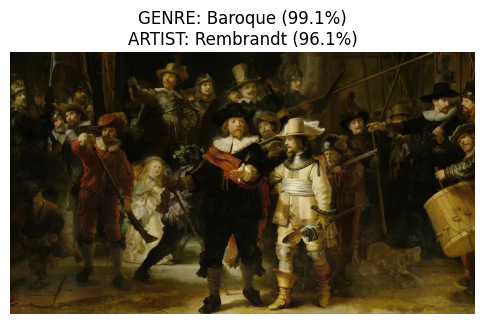

In [ ]:
#13
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_artwork(img_path, model, artist_dict, genre_dict):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Returns list of two outputs
    genre_preds, artist_preds = model.predict(img_array)

    # Get results for Genre
    genre_idx = np.argmax(genre_preds[0])
    genre_conf = genre_preds[0][genre_idx] * 100

    # Get results for Artist
    artist_idx = np.argmax(artist_preds[0])
    artist_conf = artist_preds[0][artist_idx] * 100

    inv_artist_map = {v: k for k, v in artist_dict.items()}

    plt.figure(figsize=(6, 6))
    plt.imshow(image.load_img(img_path))
    plt.title(f"GENRE: {genre_dict[genre_idx]} ({genre_conf:.1f}%)\nARTIST: {inv_artist_map[artist_idx]} ({artist_conf:.1f}%)")
    plt.axis('off')
    plt.show()

# Test Upload
uploaded = files.upload()
for fn in uploaded.keys():
    predict_artwork(fn, model, train_generator.class_indices, idx_to_genre)

Generating predictions for the validation set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step


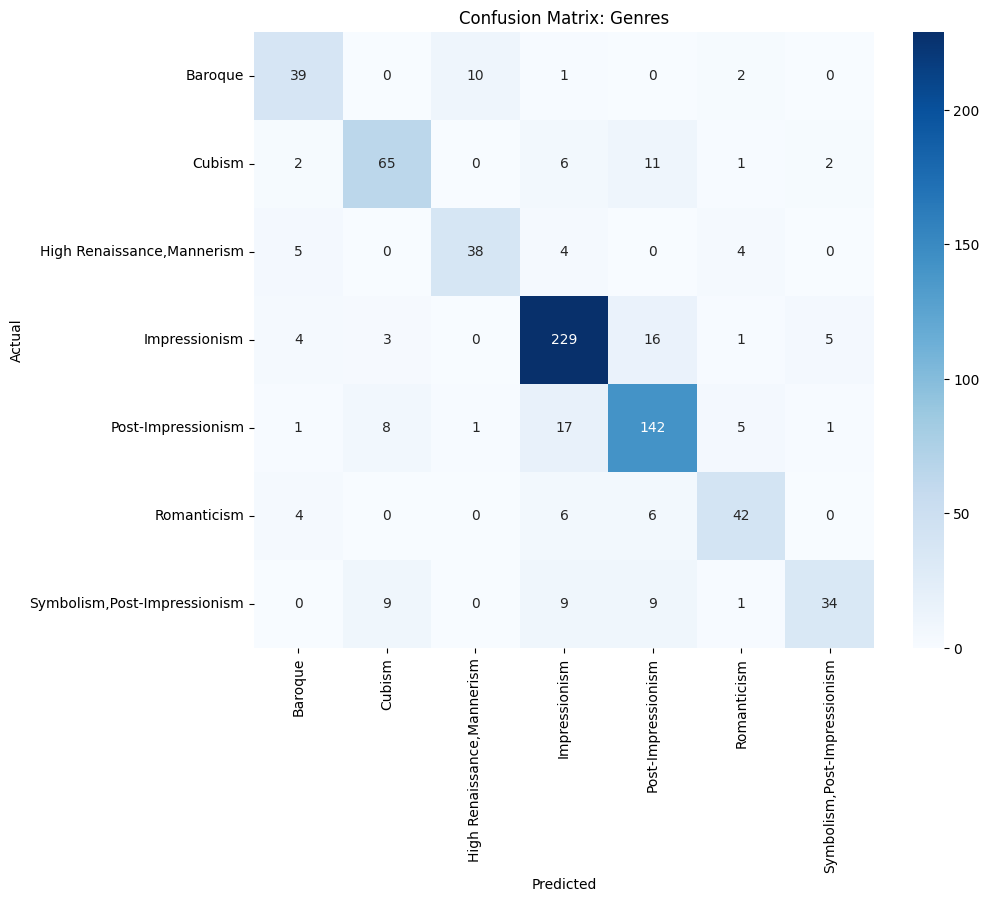

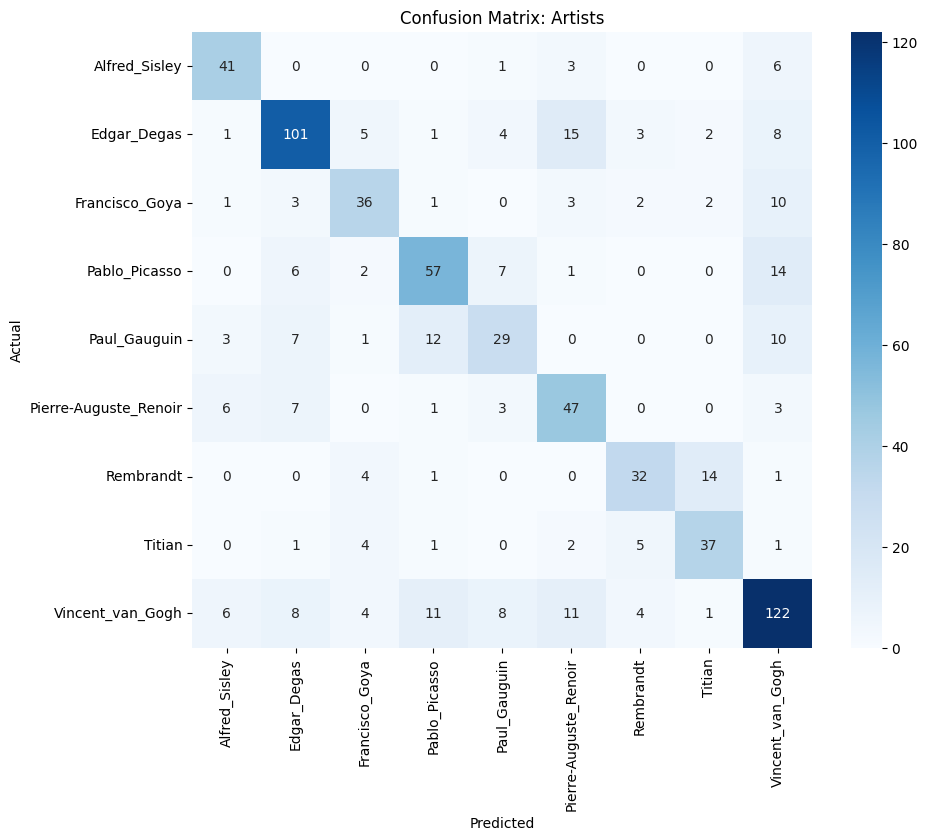


--- Detailed Genre Report ---

                              precision    recall  f1-score   support

                     Baroque       0.71      0.75      0.73        52
                      Cubism       0.76      0.75      0.76        87
  High Renaissance,Mannerism       0.78      0.75      0.76        51
               Impressionism       0.84      0.89      0.86       258
          Post-Impressionism       0.77      0.81      0.79       175
                 Romanticism       0.75      0.72      0.74        58
Symbolism,Post-Impressionism       0.81      0.55      0.65        62

                    accuracy                           0.79       743
                   macro avg       0.77      0.74      0.76       743
                weighted avg       0.79      0.79      0.79       743

-----------------------------------

--- Detailed Artist Report ---

                       precision    recall  f1-score   support

        Alfred_Sisley       0.71      0.80      0.75        51

In [ ]:
#14
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Prepare data for validation
print("Generating predictions for the validation set...")
val_generator.reset()
y_true_artist = val_generator.classes

inv_artist_indices = {v: k for k, v in val_generator.class_indices.items()}
y_true_genre = []
for idx in y_true_artist:
    artist_name = inv_artist_indices[idx]
    genre_name = artist_genre_map.get(artist_name, "Unknown")
    y_true_genre.append(genre_to_idx[genre_name])

# 2. Get model predictions
preds = model.predict(val_generator, steps=len(val_generator))
y_pred_genre = np.argmax(preds[0], axis=1)
y_pred_artist = np.argmax(preds[1], axis=1)

# 3. Visualization function
def plot_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 4. Plot Heatmaps
artist_names = list(val_generator.class_indices.keys())
genre_names = list(idx_to_genre.values())

plot_cm(y_true_genre, y_pred_genre, genre_names, 'Confusion Matrix: Genres')
print("")
plot_cm(y_true_artist, y_pred_artist, artist_names, 'Confusion Matrix: Artists')

# 5. Detailed Scientific Report
print("\n--- Detailed Genre Report ---\n")
print(classification_report(y_true_genre, y_pred_genre, target_names=genre_names))
print("-----------------------------------")
print("\n--- Detailed Artist Report ---\n")
print(classification_report(y_true_artist, y_pred_artist, target_names=artist_names))